# Validation 04 — Blast Detection (Cell 10)
Verifies onset detection, 7 s skip, noise floor, and threshold crossing.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  Onset detected (threshold crossed)  → onset at 13.60 s


  [PASS]  Onset in first half of recording  → 13.60 s / 89.25 s
  [PASS]  Useful start = onset + 7 s
  [PASS]  Useful signal non-empty  → 68.65 s
  [PASS]  Noise floor > 0  → 0.000016
  [PASS]  RMS at onset > threshold
  [PASS]  Useful signal shorter than full signal
  [PASS]  ONSET_OFFSET_S = 7.0 (midpoint of 6–8 s)
  [INFO]  Noise floor: 0.000016
  [INFO]  Onset time: 13.600 s
  [INFO]  Useful from: 20.600 s
  [INFO]  Useful duration: 68.65 s


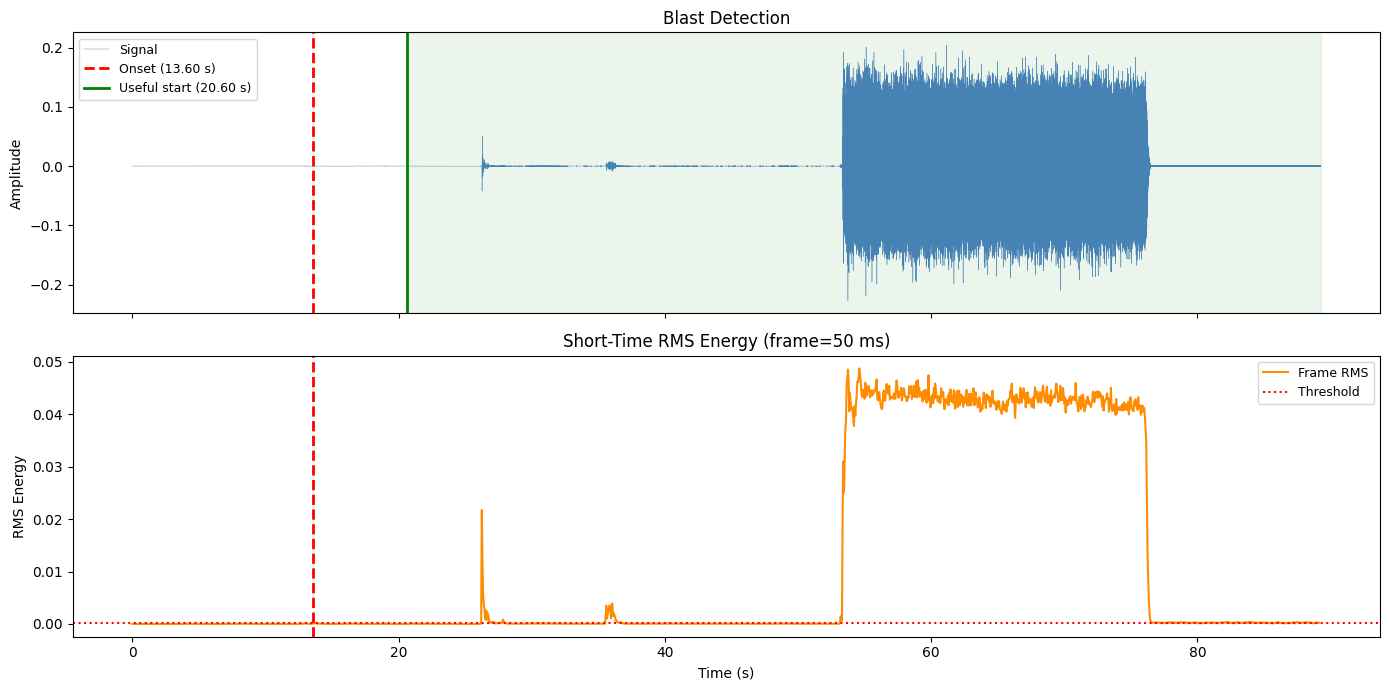


  PASS: 8/8  |  FAIL: 0/8
  Score: 100%


In [3]:
if not EXAMPLE_WAV: raise SystemExit
fs,signal,duration = load_wav(EXAMPLE_WAV)
t = np.arange(len(signal))/fs

onset_sample,onset_time,frame_times,rms_energy,noise_floor = detect_onset(signal,fs)
useful_start_time   = onset_time+ONSET_OFFSET_S
useful_start_sample = int(useful_start_time*fs)
useful_signal       = signal[useful_start_sample:]

check("Onset detected (threshold crossed)",
      np.any(rms_energy>ONSET_THRESHOLD*noise_floor), f"onset at {onset_time:.2f} s")
check("Onset in first half of recording",    onset_time<duration/2,   f"{onset_time:.2f} s / {duration:.2f} s")
check("Useful start = onset + 7 s",         abs(useful_start_time-(onset_time+ONSET_OFFSET_S))<0.001)
check("Useful signal non-empty",             len(useful_signal)>0,     f"{len(useful_signal)/fs:.2f} s")
check("Noise floor > 0",                     noise_floor>0,            f"{noise_floor:.6f}")
check("RMS at onset > threshold",
      rms_energy[int(onset_time/ENERGY_WINDOW_S)] > ONSET_THRESHOLD*noise_floor)
check("Useful signal shorter than full signal", len(useful_signal)<len(signal))
check("ONSET_OFFSET_S = 7.0 (midpoint of 6–8 s)", ONSET_OFFSET_S==7.0)

info("Noise floor",     f"{noise_floor:.6f}")
info("Onset time",      f"{onset_time:.3f} s")
info("Useful from",     f"{useful_start_time:.3f} s")
info("Useful duration", f"{len(useful_signal)/fs:.2f} s")

fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,7),sharex=True)
ax1.plot(t,signal,lw=0.3,color='steelblue',label='Signal')
ax1.axvline(onset_time,color='red',lw=2,ls='--',label=f'Onset ({onset_time:.2f} s)')
ax1.axvline(useful_start_time,color='green',lw=2,label=f'Useful start ({useful_start_time:.2f} s)')
ax1.axvspan(useful_start_time,t[-1],alpha=0.08,color='green')
ax1.legend(fontsize=9); ax1.set_ylabel('Amplitude'); ax1.set_title('Blast Detection')
ax2.plot(frame_times,rms_energy,color='darkorange',label='Frame RMS')
ax2.axhline(ONSET_THRESHOLD*noise_floor,color='red',ls=':',lw=1.5,label='Threshold')
ax2.axvline(onset_time,color='red',lw=2,ls='--')
ax2.legend(fontsize=9); ax2.set_xlabel('Time (s)'); ax2.set_ylabel('RMS Energy')
ax2.set_title(f'Short-Time RMS Energy (frame={ENERGY_WINDOW_S*1000:.0f} ms)')
plt.tight_layout(); plt.show(); plt.close('all')
summary()
